https://www.youtube.com/watch?v=VMj-3S1tku0

Micrograd is basically an autograd engine. Autograd is short for automatic gradient and really what it does is, it implements backpropagation. Now backpropagation is this algorithm that allows you to efficiently evaluate the gradient of some kind of a loss function with respect to the weights of a neural network and what that allows us to do then is we can iteratively tune the weights of that neural network to minimize the loss function and therefore improve the accuracy of the network.

So backpropagation would be at the mathematical core of any modern deep neural network library like say PyTorch or JAX.

So the functionality of micrograd is I think best illustrated by an example. So if we just scroll down here, you'll see that micrograph basically allows you to build out mathematical expressions and um here what we are doing is we have an expression that we're building out where you have two inputs a and b. and you'll see that a and b are -4 and 2 but we are wrapping those values into this value object that we are going to build out as part of micrograd.

So this value object will wrap the numbers themselves and then we are going to build out a mathematical expression here where a and b are transformed into c d and eventually e f and g

and I'm showing soem of the functions some of the functionality of micrograph and the operations that it supports. So you can add two value objects, you can multiply them, you can raise them to a constant power, you can offset by 1, negate, squash at zero, square, divide by constant, divide by it, etc.

And so we're building out an expression graph with these two inputs a and b and we're creating an output value of g and micrograd will in the background build out this entire mathematical expression. So it will for example know that c is also a value. c was a result of an addition operation and the child nodes of c are a and b because the *** will maintain pointers to a and b value objects. So we'll basically know exactly how all of this is laid out.

And then not only can we do what we call the forward pass where we actually look at the value of g of course. That's pretty straightforward, we will acess that using the .data attribute and so the output of the forward pass the value of g is 24.7 it turns out. But the big deal is that we can also take this g value object and we can call .backward()

And this will basically uh initialize backpropagation at the node g and what backpropagation is going to do is it's going to start at g and it's going to go backwards through that expression graph and it's going to recursively apply the chain rule from calculus and what that allows us to do then is we're going to evaluate basically the derivative of g with respect to all the internal nodes like e d and c but also with respect to the inputs a and b and then we can actually query this derivative of g with respect to a for example that's a.grad in this case it happens to be 138 and the derivative of g with respect to b which also happens to be here 645 and this derivative we'll see soon is very important information because it's telling us how a and b are affecting g through this mathematical expression.

So in particular a.grad is 138. So if we slightly nudge a and make it slightly larger, 138 is telling us that g will grow and the slope of that growth is going to be 138 and the slope of growth of b is going to be 645. So that's going to tell us about how g will respond if a and b get tweaked a tiny amount in a positive direction.

Neural networks are just a mathematical expression, they take the input data as an input and they take the weights of a neural network as an input and it's a mathematical expression and the output are your predictions of your neural net or the loss function.

we'll see this in a bit but basically neural networks just happen to be a certain class of mathematical expressions but backpropagation is actually signfiicantly more general. it doesn't actually care about neural networks at all.

it only tells us about arbitrary mathematical expressions and then we happen to use that machinery for training of neural networks.

now, one more note i would like to make at this stage, is that as you see here micrograd is a scalar valued autograd engine. So it's working on the you know level of individual scalars like -4 and 2, and we're taking neural nets and we're breaking them down all the way to these atoms of individual scalars and all the little pluses and times and it's just excessive and so obviously you would never be doing any of this in production. it's really just put down for pedagogical reasons because it allows us to not have to have deal with these n-dimensional tensors that you would use in modern deep neural network library.

so this is really done so that you understand and refactor out backpropagation and chian rule and understanding neural training and then if you actually want to train bigger networks you have to be using these tensors but none of the math changes. This is done purely for efficiency, we are basically taking scalar value, all the scalar values, we're packaging them up into tensors which are just arrays of these scalars and then because we have these large arrays, we're making operations on those large arrays that allows us to take advantage of the parallelism in a computer and all those operations can be done in parallel and then the whole thing runs faster but really none of the mth changes and that's done purely for efficiency. so i don't think that's pedagogically useful to be dealing with tensors from scratch. and that's why i fundamentally wrote micrograd, because you can understand how things work at the fundamental level and then you can speed it up later.

so here is the fun part, my claim is that micrograd is what you need to train your neural networks and everything else is just efficiency. so, you'd think that micrograd would be a very compelx piece of code and that turns out to not be the case. so if we just go to micrograd, and you'll see that there's only two files here in micrograd. this is the actual engine, it doesn't know anything about neural nets and this is the entire neural nets library on top of micrograd. so, engine and nn.py. so the actual backpropagation autograd engine that gives you the power of neural networks is literally 100 lines of code of like very simple python which we'll understand by the end of this lecture.

and then nn.pi, this neural network library built on top of the autograd engine is like a joke, it's like, we have to define what is a neuron, and then we have to define what is the layer of neurons, and then we define what is a multi-layer perceptron, which is just a sequence of layers of neurons, and so it's just a total joke.

so basically there's a lot of powers that comes from only 150 lines of code and that's all you need to understand, to understand neural network training and everything else is just efficiency and of course there's a lot to efficiency but fundamentally that's all that's happening.

In [307]:
from typing import Set, Tuple, Union
import math
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
  return 3*x**2 - 4*x + 5
  # differentiating f(x) with respect to x
  # 6x - 4
  # suppose x = 3
  # 6(3) - 4 = 14

In [3]:
f(3.0)

20.0

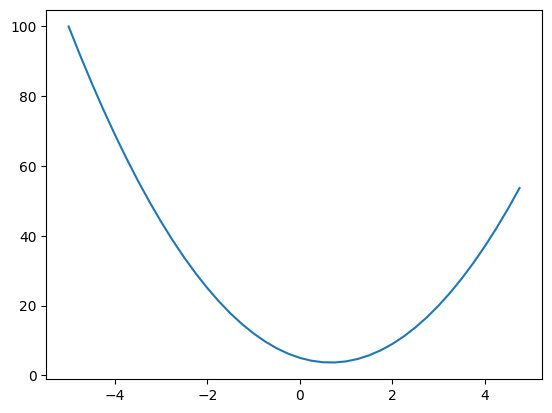

In [7]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
h = 0.001
x = 3.0
(f(x+h) - f(x))/h # numerical approximation of the slope

14.00300000000243

In [12]:
# let's get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


now what i have to do is i'd like to again look at the derivatives of d with respect to a, b, and c. and think through again just the intuition of what this derivative is telling us

In [16]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print("d1", d1)
print("d2", d2)
print("slope", (d2 - d1)/h)
# a += h
# you can convince yourself that -3 is the right answer mathematically and analytically
# because if you have a * b + c and you are you know you have calculus
# then differentiating a * b + c with respect to a gives you just b
# and indeed the value of b is -3 which is the derivative that we have. so you can tell that that's correct.
# so now if we do this with b, so if we bump b by a little bit in a positive direction we'd get different slopes

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [325]:
class Value:
  def __init__(self, data: float, _children=(), _op='', label=""):
    self.data = data
    self.grad = 0
    # grad is representing the derivative of the output
    # in this case with respect to this value
    # so this is the derivative of L with respect to f, with respect to d, and so on
    # if the gradient is 0 that means changing this variable
    # is not changing the loss function
    self._backward = lambda: None
    # this will be a function which is going to do that little piece of chain rule
    # at each little node that took input and produce output
    # we are going to store
    # how we are going to chain the the outputs gradient into the inputs gradients
    # so by default, this will be a function that doesn't do anything
    # that would be the case for example for a leaf node, for a leaf node there's nothing to do.
    # but now if when we're creating these out values, these out values are an addition
    # of self and other
    # and so we will want to set outs backward to be the function that propagates
    # the gradient
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other: Union[int, float, "Value"]) -> "Value":
    other = other if isinstance(other, Value) else Value(data=other)
    # to support use case
    # a = Value(data=2.0)
    # a + 3
    out = Value(data=self.data + other.data, _children=(self, other), _op='+')

    def _backward(): 
      """
      for addition, our job is to take outs grad and propagate it into self's grad and other grad

      the way we saw below how chain rule works we want to take the local gradient *
      the global derivative which is the derivative of the final output with respect to
      out's data

      so the local derivative of self in an addition is 1.0
      """
      self.grad += 1.0 * out.grad
      """
      there was a bug
      basically we're going to see an issue anytime we use a variable more than once
      if a variable is used more than once
      what' going to happen during backward pass we're backpropagating from f to e to d so far
      so good but now e calls backward and it deposits its gradient into a and b
      but then we come back to d and call backward, and it overrides those gradients at a and b
      so that's obviously a problem
      and the solution here if you look at the multivariate case of the chain rule and
      its generalization there
      the solution there is basically that we have to accumulate these gradients
      these gradients add and so instead of setting those gradients
      we can do simply +=
      """
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out
  
  def __radd__(self, other: Union[int, float]) -> "Value": # other + self
    """
    to support use case
    a = Value(data=2.0)
    3 + a
    """
    return self + other
  
  def __mul__(self, other: "Value") -> "Value":
    other = other if isinstance(other, Value) else Value(data=other)
    # to support use case
    # a = Value(data=2.0)
    # a * 2
    out = Value(data=self.data * other.data, _children=(self, other), _op='*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other: Union[int, float]) -> "Value": # other * self
    """
    to support use case
    a = Value(data=2.0) 
    2 * a
    """
    return self * other
  
  def __pow__(self, other: Union[int, float]) -> "Value":
    assert isinstance(other, (int, float)), "only supporting int and float for now"
    out = Value(data=self.data**other, _children=(self, ), _op="**{other}")

    def _backward():
      self.grad += other * self.data**(other-1) * out.grad
    out._backward = _backward

    return out
  
  def __truediv__(self, other: "Value") -> "Value": # self / other
    return self * other**-1
  
  def __neg__(self) -> "Value": # -self
    return self * -1
  
  def __sub__(self, other: Union[int, float, "Value"]) -> "Value": # self - other
    return self + (-other)
  
  def tanh(self) -> "Value":
    """
    now one option here is we could actually implement
    exponentiation
    and we can return the x of a value instead of tanh of a value
    because if we had x then we have everything else that we need
    because we know how to add and we know how to multiply
    so we'd be able to create tanh if we knew how to x
    but for the purpose of this example I specifically wanted to show you
    that we don't necessarily need to have the most atomic pieces
    in this value object
    we can actually like create functions at arbitrary points of abstraction
    they can be complicated functions but they can be also very very simple functions
    like a plus and it's totally up to us the only thing that matters is that
    we know how to differentiate through any one function.
    so we take some inputs and we make an output. the only thing that matters
    it can be arbitrarily complex function as long as you know how to create
    the local derivative, if you know the local derivative of how the inputs
    impact the output, then that's all you need.
    so we're going to cluster up all of this expression and we're not
    going to break it down to its atomic pieces we're just going to directly
    implement tanh.
    so let's do that
    """
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    out = Value(data=t, _children=(self, ), _op='tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out
  
  def exp(self) -> "Value":
    x = self.data
    out = Value(data=math.exp(x), _children=(self, ), _op='exp')

    def _backward():
      self.grad += out.data * out.grad
      # dout/dx = dout/dexp * dexp(x)/dx
      # 
      # dexp(x)/dx = exp(x)
    out._backward = _backward

    return out
  
  def backward(self):
    topo: list["Value"] = []
    visited: Set["Value"] = set()
    def build_topo(v: Value):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

  
a = Value(data=2.0, label="a")
b = Value(data=-3.0, label="b")
c = Value(data=10.0, label="c")
e = a*b; e.label = "e"
d = e + c; d.label = "d"
f = Value(data=-2.0, label="f")
L = d * f; L.label="L"
L

Value(data=-8.0)

In [298]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

In [ ]:
# if we have divide a by b
# that's actually the same as, a multiplying one over b
# and that's the same as, a multiplying b to the power of -1
a / b
a * (1/b)
a * (b**-1)

# and so what I'd like to do instead is I basically
# liek to implement operation of x to the k for some constant uh k
# so it's an integer or a float and we would like to be able to differentiate this
# and then as a special case -1 will be division
# and so I'm doing just that just because it's more general and
# you might as well do it that way
# x**k

In [83]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [84]:
d._op

'+'

In [260]:
from graphviz import Digraph

def trace(root: Value) -> Tuple[Set[Value], Set[Tuple[Value, Value]]]:
  # builds a set of all nodes and edges in a graph
  nodes: Set[Value] = set()
  edges: Set[Tuple[Value, Value]] = set()
  def build(v: Value) -> None:
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root: Value):
  dot = Digraph(format="svg", graph_attr={"rankdir": "LR"}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name=uid, label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape="record")
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name=uid + n._op, label=n._op)
      # and connect this node to it
      dot.edge(tail_name=uid + n._op, head_name=uid)
  
  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(tail_name=str(id(n1)), head_name=str(id(n2)) + n2._op)
  
  return dot

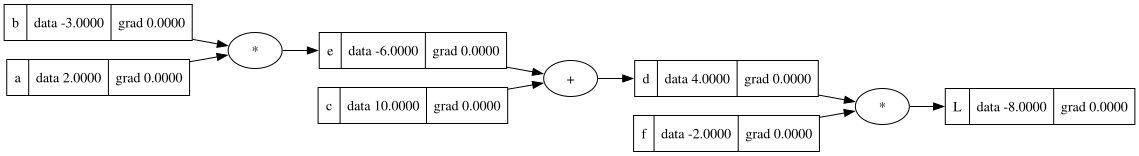

In [263]:
draw_dot(L)

In [ ]:
# L = d * f

# dL/dd = f
# (f(x+h) - f(x))/h
#
# ((d+h)*f - d*f)/h
# (d*f + h*f - d*f) / h = f

In [ ]:
L.grad = 1.0 # dL/dL = 1.0
f.grad = 4.0 # dL/df = d = 4.0
d.grad = -2.0 # dL/dd = f = -2.0
c.grad = -2.0 # dL/dc = dL/dd * dd/dc = -2.0
e.grad = -2.0 # dL/de = dL/dd * dd/de = -2.0
a.grad = (-2.0) * (-3.0) # dL/da = dL/de * de/da = -2.0 * -3.0 = 6.0
b.grad = -2.0 * 2.0
# dL/db = dL/de * de/db = -2.0 * 2.0 = -4.0
#                 local gradient

in the neural network setting you'd be very interested in the derivative of basically this loss function L with respect to the weights of a neural network and here we have just these variables a b c and f but some of these will eventually represent the weights of a neural net and so we'll need to know how those weights are impacting the loss function. so we'll be interested in the derivative of the output with respect to soem of its leaf nodes. and those leaf nodes will be the weights of the neural nets.

and the other leaf nodes of course will be the data itself but usually we will not want or use the derivative of the loss function with respect to data because the data is fixed but the weights will be iterated on using the gradient information. 

so next we are going to create a variable inside the value class that maintains the derivative of L with respect to that value. we will call this value grad.

now we're getting to the crux of backpropagation. so this is the important node to understand because if you understand the gradient for this node, you understand all of back propagation and all of training of neural nets. So we need to derive dL / dc. In other words the derivative of L with respect to c

so just very intuitively if you know the impact that c is having on d and the impact of d is having on L. then you should be able to somehow put that information together to figure out how c impact L

concentrating on d first
let's look at how what is derivative basically of d with respect to c. so in other words, what is dd by dc.

how do we put that information together to write dL/dc ?
the answer is chain rule.

dL/dc = dL/intermediate variable * intermediate variable/dc

In [ ]:
# dd/dc = 1.0
# dd/de = 1.0
# d = c + e
# (f(x+h) - f(x)) / h <- definition of derivative
# 
# ((c+h + e) - (c + e))/h = 1.0

# WANT:
# dL/dc = (dL/dd) * (dd/dc)
# that's chain rule
#
# KNOW:
# dL/dd
# dd/dc
#

# KNOW:
# dL/de = -2.0
# e = a * b
# de/da = b = -3.0
# WANT:
# dL/da = (dL/de) * (de/da) = 6.0

we iterated through all the nodes and locally applied the chain rule, we always know what is the derivative of L with respect to this little output then we look at how this output was produced. this output was produced through some operation and we have the pointers to the children nodes of this operation.

and so in this little operation, we know what the local derivatives are, and we just multiply them onto the derivative always. so we just go through and recursively multiply on the local derivatives and that's what back propagation is. it's just a recursive application of chain rule.

In [ ]:
# this is one optimization step
# 0.01 is the learning rate
# a, b, c, f those are leaf nodes which usually we have control of
# if we nudge in direction of the gradient we expect a positive influence on L
# so we expect L to go up positively, so it should become less negative
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a*b
d = e + c
L = d * f

print(L.data) # before it was -8.0 now it's -7.2, happy days

-7.286496


In [ ]:
def lol():
  # we've numerically verified
  # what we're doing here is what kind of like an inline gradient check
  # gradient check is when we are deriving this like back propagation and
  # getting the derivative with respect to all the intermediate results
  # and then numerical gradient is just you know estimating it using small
  # step size

  h = 0.0001

  a = Value(2.0, label="a")
  b = Value(-3.0, label="b")
  c = Value(10.0, label="c")
  e = a*b; e.label = "e"
  d = e + c; d.label = "d"
  f = Value(-2.0, label="f")
  L = d * f; L.label="L"
  L1 = L.data

  a = Value(2.0, label="a")
  b = Value(-3.0, label="b")
  b.data += h
  c = Value(10.0, label="c")
  e = a*b; e.label = "e"
  d = e + c; d.label = "d"
  f = Value(-2.0, label="f")
  L = d * f; L.label="L"
  L2 = L.data

  print((L2 - L1)/h)

lol()

-4.000000000008441


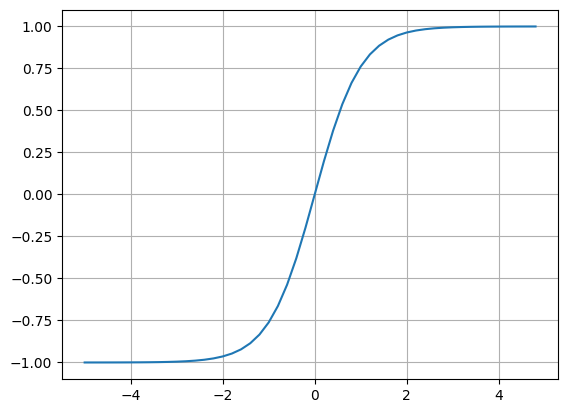

In [116]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

In [300]:
# inputs x1,x2
x1 = Value(data=2.0, label="x1")
x2 = Value(data=0.0, label="x2")
# weights w1,w2
w1 = Value(data=-3.0, label="w1")
w2 = Value(data=1.0, label="w2")
# bias of the neuron
b = Value(data=6.8813735870195432, label="b")
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1 + x2w2"
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label = "o"
o.backward()

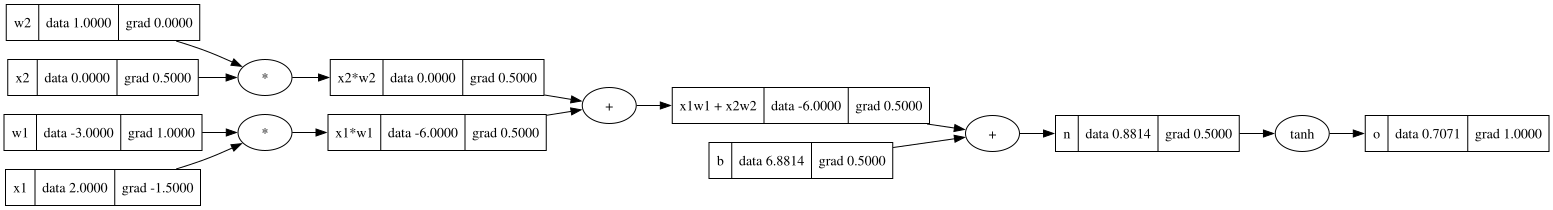

In [301]:
draw_dot(o)

In [275]:
o.backward()

this ordering of graphs can be achieved using something called topological sort. so topological sort is basically a laying out of a graph such that all the edges go only from left to right.
so here we have a graph, it's a directory, a cyclic graph, a dag, and this is two different topological orders of it. I believe where basically you'll see that it's laying out of the nodes such that all the edges go only one way from left to right
and implementing topological sort, you can look in wikipedia and so on
i am not going to go through it in detail but basically this is what builds a topological graph

we maintain a set of visited nodes and then we are going through starting at some root node which for us is o, that's where we want to start the topological sort and starting at o we go through all of its children and we need to lay them out from left to right
and basically this starts at o if it's not visited then it marks it as visited and then it iterates through all of its children and calls build topological on them and then after it's gone through all the children it adds itself

so basically this node that we're going to call it on like say o is only gonig to add itself to the topo list after after all of the children have been processed

In [268]:
o.grad = 1.0

topo: list[Value] = []
visited: Set[Value] = set()
def build_topo(v: Value):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)

for node in reversed(topo):
  node._backward()

In [269]:
topo = []
visited = set()
def build_topo(v: Value):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [270]:
o.grad = 1.0

In [271]:
o._backward()

In [272]:
n._backward()

In [220]:
b._backward() # nothing will happen because b is a leaf node

In [221]:
x1w1x2w2._backward()

In [223]:
x2w2._backward()
x1w1._backward()

In [ ]:
o.grad = 1.0 # do/do = 1.0

n.grad = 0.5 # do/dn = 1 - tanh(n)**2 = 1 - o**2 = 0.5

x1w1x2w2.grad = 0.5
b.grad = 0.5

x1w1.grad = 0.5
x2w2.grad = 0.5

x2.grad = x2w2.grad * w2.data # do/dx2 = do/dx2w2 * dx2w2/dx2
w2.grad = x2w2.grad * x2.data # do/dw2 = do/dx2w2 * dx2w2/dw2

x1.grad = x1w1.grad * w1.data # do/dx1 = do/dx1w1 * dx1w1/dx1
w1.grad = x1w1.grad * x1.data # do/dw1 = do/dx1w1 * dx1w1/dw1

In [128]:
1 - o.data**2

0.4999999999999999

In [ ]:
# o = tanh(n)
# do/dn = 1 - tanh(n)**2 = 1 - o**2

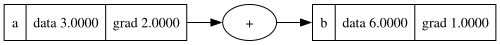

In [277]:
a = Value(3.0, label="a")
b = a + a; b.label = "b"
b.backward()
draw_dot(b)

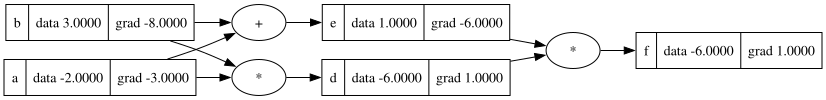

In [278]:
a = Value(-2.0, label="a")
b = Value(3.0, label="b")
d = a * b; d.label="d"
e = a + b; e.label="e"
f = d * e; f.label="f"

f.backward()

draw_dot(f)

the reason i want to go through this exercise is
1. we got to practice a few more operations and writing more backwards passes
2. i wanted to illustrate the point that the level at which you implement your operation is totally up to you, you can implement backward passes for tiny expressions like a single individual + or single * or you can implement them for say tanh
which is a kind of potentially you can see it as a composite operation because it's made up of all these more atomic operations but really all of this is kind of like a fake concept
all that matters is we have some kind of inputs and some kind of an output and this output is a function of the inputs in some way and as long as you can do forward pass and the backward pass of that little operation it doesn't matter what that operation is and how composite it is. if you can write the local gradients, you can chain the gradient and you can continue back propagation so the design of what those functions are is completely up to you

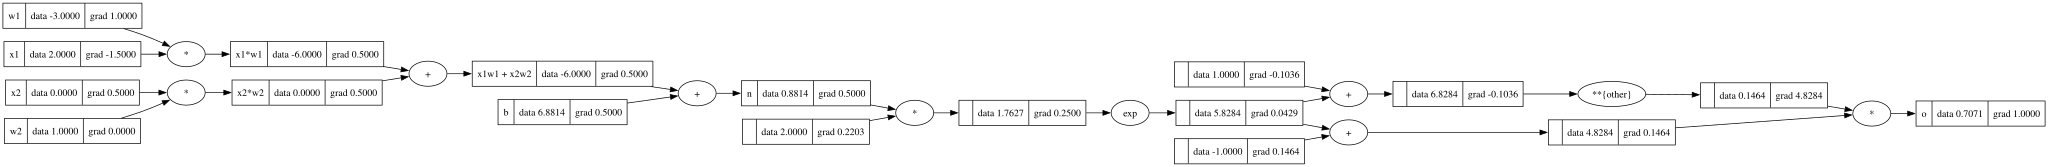

In [ ]:
# inputs x1,x2
x1 = Value(data=2.0, label="x1")
x2 = Value(data=0.0, label="x2")
# weights w1,w2
w1 = Value(data=-3.0, label="w1")
w2 = Value(data=1.0, label="w2")
# bias of the neuron
b = Value(data=6.8813735870195432, label="b")
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1 + x2w2"
n = x1w1x2w2 + b; n.label = "n"
# ---
e = (2 * n).exp()
o = (e - 1) / (e + 1)
# equivalent to o = n.tanh()
# ---
o.label = "o"
o.backward()
draw_dot(o)

In [306]:
import torch

x1 = torch.Tensor([2.0]).double()                 ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                 ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()                ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                 ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()   ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [394]:
class Neuron:
  def __init__(self, nin: int):
    """
    nin: number of inputs
    """
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1, 1))

  def __call__(self, x: list[Union[int, float]]) -> Value:
    # w * x + b
    act: Value = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]
  
class Layer:
  def __init__(self, nin: int, nout: int):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x: list[Union[int, float]]) -> Union[list[Value], Value]:
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

    # params: list[Value] = []
    # for neuron in self.neurons:
    #   ps = neuron.parameters()
    #   params.extend(ps)
    # return params
  
class MLP:
  def __init__(self, nin: int, nouts: list[int]):
    sz = [nin] + nouts # sizes of the layers
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [402]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.9032329795321011)

In [403]:
len(n.parameters())

41

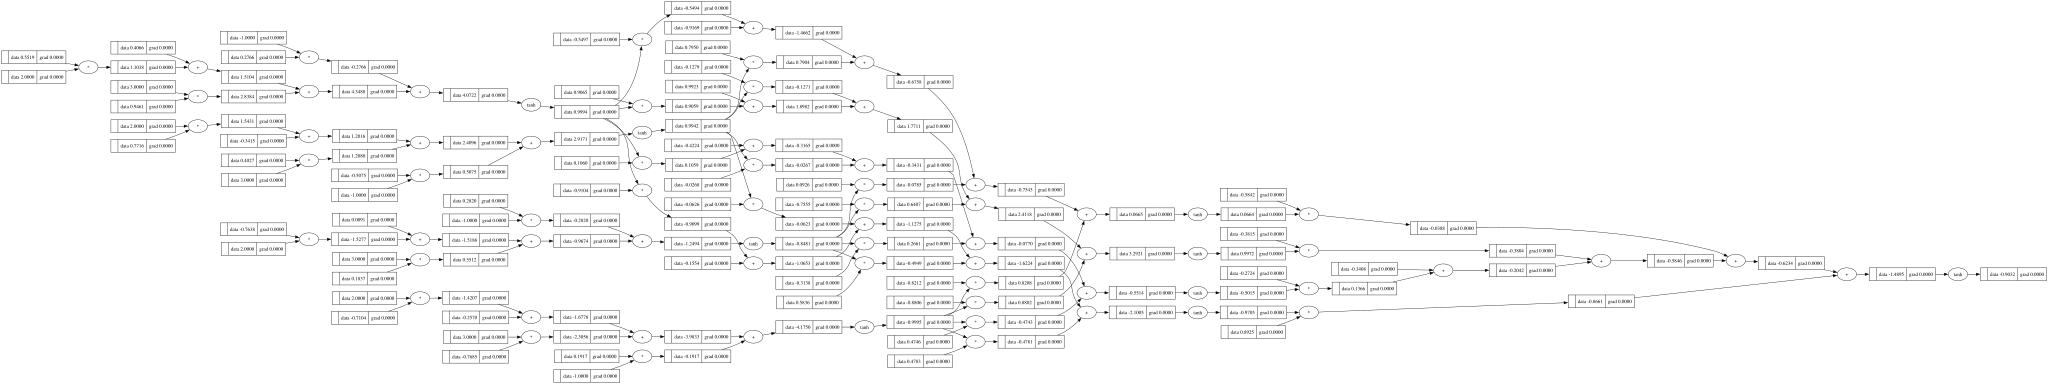

In [404]:
draw_dot(n(x))

how do we make the neural nets and how do we tune the weights to better predict the desired targets

and the trick used in deep learning to achieve this is to calculate a single number that somehow measures the total performance of your neural net and we call this single number the loss

In [405]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [414]:
for k in range(20):
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad
  
  print(k, loss.data)
  

0 0.010605655495472679
1 0.01051934723340867
2 0.010434408228830743
3 0.010350806448936413
4 0.010268510846635914
5 0.010187491323078985
6 0.010107718691873548
7 0.010029164644907303
8 0.009951801719689535
9 0.009875603268135453
10 0.009800543426718409
11 0.009726597087921842
12 0.009653739872924954
13 0.009581948105460437
14 0.009511198786786548
15 0.009441469571718309
16 0.009372738745665935
17 0.009304985202632112
18 0.009238188424121203
19 0.00917232845891693


In [415]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
# mean squared error
loss

Value(data=0.009107385903687412)

In [401]:
loss.backward()

In [370]:
n.layers[0].neurons[0].w[0].grad
# -0.08
# because this gradient here on this particular weight, of this particular neuron
# of this particular layer is negative
# we see that its influence on the loss is also negative
# so slightly increasing this particular weight of this neuron of this layer
# would make the loss go down
# and we actually have this information for every single one of our neurons and all their parameters
# actually it's worth looking at also the draw_dot(loss)

0.5029605955602202

In [371]:
n.layers[0].neurons[0].w[0].data

-0.2574173026541058

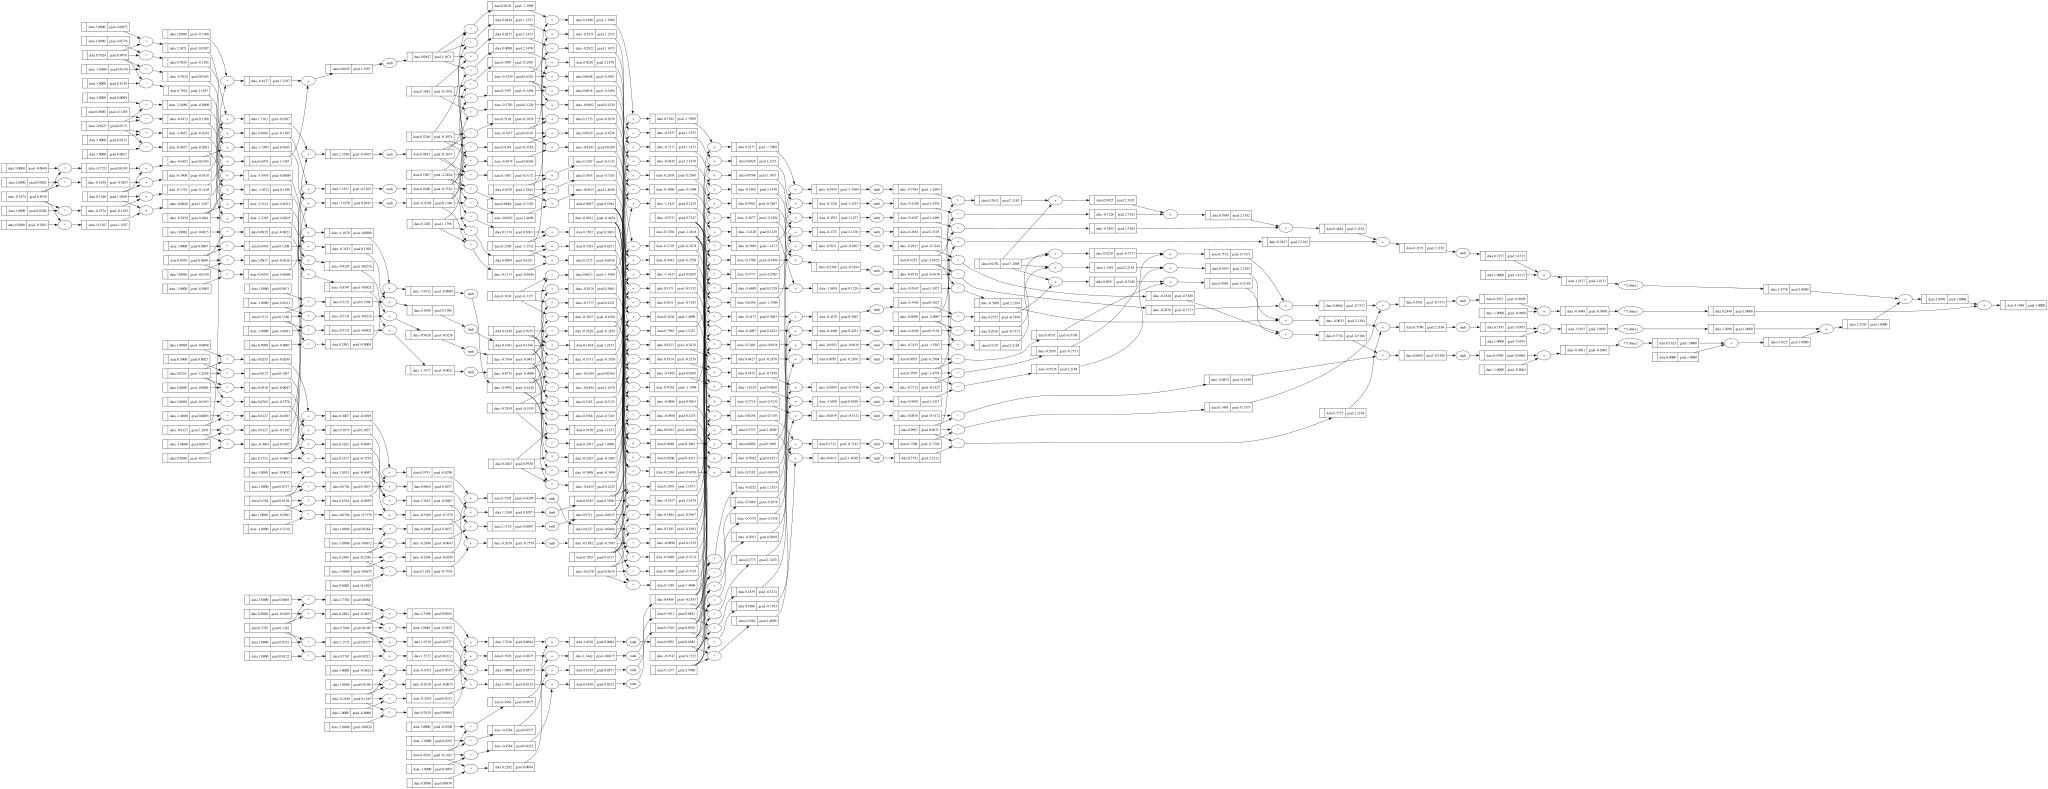

In [372]:
draw_dot(loss)

In [416]:
for p in n.parameters():
  # in gradient descent we are thinking of the gradient
  # as a vector pointing in the direction of increased loss
  # and so in gradient descent we are modifying 
  # p.data by a small step size in the direction of the gradient
  # so the step as an example could be 0.01
  # but we have think through some of the signs here
  # so in particular, in working with this specific example here
  # we see that if we just left it like this (p.grad is -0.279 and p.data is 0.85)
  # then this neuron's value would be currently increased by a tiny amount of the gradient
  # the graident is negative so this value would go slightly down
  # it would become like 0.84 or something like that
  # but if this neuron's value goes lower
  # that would actually increase the loss
  # that's because the derivative of this neuron is negative.
  # so increasing this makes the loss go down
  # so increasing it is what we want to do instead of decreasing it
  # so basically what we're missing here is we're actually missing a negative sign
  # and again this other interpretation
  # and that's because we want to minimize the loss
  # we don't want to maximize the loss, we want to decrease it
  # and the other interpretation as i mentioned
  # you can think of the gradient vector
  # so basically just the vector of all the gradients
  # as pointing in the direction of increasing the loss
  # but we want to decrease it, so we actually want to go in the opposite direction
  # and so you can convince yourself that this sort of does the right thing here
  # with the negative because we want to minimize the loss
  # so if we nudge all the parameters by tiny amount
  # then we'll see that this data will have changed a little bit so now
  # this neuron is a tiny amount greater value
  p.data += -0.01 * p.grad

In [374]:
n.layers[0].neurons[0].w[0].data

-0.262446908609708

In [417]:
ypred

[Value(data=0.9579383165730724),
 Value(data=-0.965492957758408),
 Value(data=-0.9419009446751306),
 Value(data=0.9473505508378759)]